In [1]:
import tensorflow as tf
import optuna
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE=32


In [3]:
# ============================================
# IMAGE DATA GENERATOR
# ===========================================

train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=20,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True,
)

validation_datagen = ImageDataGenerator(
  rescale=1./255,
)


In [4]:
# ============================================
# LOAD IMAGE
# ===========================================

train_dir = "dataset/train"
validation_dir = "dataset/val"
test_dir = "dataset/test"

train_data = train_datagen.flow_from_directory(
  train_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' 
)

validation_data = validation_datagen.flow_from_directory(
  validation_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' 
)

test_data = validation_datagen.flow_from_directory(
  test_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary',
  shuffle=False
)

print(train_data.class_indices)




Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [ ]:
# ============================================
# TUNING WITH BAYESIAN
# ===========================================

def objective(trial: optuna.Trial):
  # feature_map layer 1
  features_1 = trial.suggest_categorical(
    "features_1",
    [32, 64]
  )

  # features_map layer 2 
  features_2 = trial.suggest_categorical(
    "features_2",
    [64, 128],
  )
  
  #features_map layer 3
  features_3 = trial.suggest_categorical(
    "features_3",
    [128,  256],
  )

  # fully_connected newuron
  dense_unit_1 = trial.suggest_int(
    "dense_unit_1",
    64, 
    256,
    step=64
  )

  dense_unit_2 = trial.suggest_int(
    "dense_unit_2",
    64, 
    256,
    step=64
  )

  # dropout
  dropout_rate_1 = trial.suggest_float(
    "dropout_rate_1",
    0.2, 
    0.5
  )
  
  dropout_rate_2 = trial.suggest_float(
    "dropout_rate_2",
    0.2, 
    0.5
  )

  # learning rate
  learning_rate = trial.suggest_float(
    "learning_rate",
    1e-4, 
    1e-2,
    log=True
  )

  # ============================================
  # BUILD MODEL
  # ===========================================
  model = tf.keras.Sequential([

    # CNN Layer 1
    tf.keras.layers.Conv2D(
      features_1,
      (3, 3),
      activation='relu',
      padding='same',
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

    # CNN layer 2
    tf.keras.layers.Conv2D(
      features_2,
      (3, 3),
      activation='relu',
      padding='same'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
    
    # CNN layer 3
    tf.keras.layers.Conv2D(
      features_3,
      (3, 3),
      activation='relu',
      padding='same'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

    # flatten
    tf.keras.layers.Flatten(),

    # fully connected layer
    tf.keras.layers.Dense(
      dense_unit_1,
      activation='relu'
    ),

    tf.keras.layers.Dropout(
      dropout_rate_1,
    ),

    tf.keras.layers.Dense(
      dense_unit_2,
      activation='relu'
    ),

    tf.keras.layers.Dropout(
      dropout_rate_2,
    ),

    # output
    tf.keras.layers.Dense(
      1,
      activation='sigmoid'
    )
  ])


  # optimizer
  model_optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
  )
  model.compile(
    optimizer=model_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

  #early stop
  class stopWithThreshold(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') > 0.95:
            print("\nReached 95% accuracy so cancelling training!")
            self.model.stop_training = True

  early_stop = stopWithThreshold()
  history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    verbose=0,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
  )

  loss, accuracy = model.evaluate(
    test_data,
    verbose=0
  )

  return accuracy

In [18]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(
    direction='maximize',
)

# =========================================================
# START OPTIMIZATION
# =========================================================

study.optimize(
  objective,
  n_trials=20,
)

print("\nBest Hyperparameters:")
print(study.best_params)

print("\nBest Accuracy:")
print(study.best_value)


[I 2026-05-18 21:20:48,249] A new study created in memory with name: no-name-0cf50cd1-5a7a-4b18-9f64-055378de6c76
[I 2026-05-18 21:22:46,725] Trial 0 finished with value: 0.9259259104728699 and parameters: {'features_1': 32, 'features_2': 64, 'features_3': 128, 'dense_unit_1': 192, 'dense_unit_2': 64, 'dropout_rate_1': 0.4621060783957943, 'dropout_rate_2': 0.30974014394873434, 'learning_rate': 0.003578679756098459}. Best is trial 0 with value: 0.9259259104728699.
[I 2026-05-18 21:24:38,711] Trial 1 finished with value: 0.8518518805503845 and parameters: {'features_1': 32, 'features_2': 64, 'features_3': 128, 'dense_unit_1': 256, 'dense_unit_2': 128, 'dropout_rate_1': 0.22063543494024385, 'dropout_rate_2': 0.33858839059031454, 'learning_rate': 0.000873792420026903}. Best is trial 0 with value: 0.9259259104728699.



Reached 95% accuracy so cancelling training!


[I 2026-05-18 21:27:59,972] Trial 2 finished with value: 0.9259259104728699 and parameters: {'features_1': 32, 'features_2': 64, 'features_3': 256, 'dense_unit_1': 256, 'dense_unit_2': 128, 'dropout_rate_1': 0.3092526005743123, 'dropout_rate_2': 0.45895716526842206, 'learning_rate': 0.00023381070761216267}. Best is trial 0 with value: 0.9259259104728699.



Reached 95% accuracy so cancelling training!


[I 2026-05-18 21:30:18,685] Trial 3 finished with value: 0.9629629850387573 and parameters: {'features_1': 32, 'features_2': 64, 'features_3': 256, 'dense_unit_1': 192, 'dense_unit_2': 192, 'dropout_rate_1': 0.48174795655145064, 'dropout_rate_2': 0.2090650256587396, 'learning_rate': 0.0006471478301931301}. Best is trial 3 with value: 0.9629629850387573.
[I 2026-05-18 21:34:54,352] Trial 4 finished with value: 0.8518518805503845 and parameters: {'features_1': 64, 'features_2': 64, 'features_3': 128, 'dense_unit_1': 128, 'dense_unit_2': 192, 'dropout_rate_1': 0.3027735323501609, 'dropout_rate_2': 0.32646059007155953, 'learning_rate': 0.0019505778654495827}. Best is trial 3 with value: 0.9629629850387573.
[I 2026-05-18 21:39:33,566] Trial 5 finished with value: 0.8148148059844971 and parameters: {'features_1': 32, 'features_2': 64, 'features_3': 256, 'dense_unit_1': 256, 'dense_unit_2': 128, 'dropout_rate_1': 0.3005983088726701, 'dropout_rate_2': 0.3042996616587953, 'learning_rate': 0.005

...


Reached 95% accuracy so cancelling training!


[I 2026-05-18 22:23:12,369] Trial 16 finished with value: 0.9629629850387573 and parameters: {'features_1': 32, 'features_2': 128, 'features_3': 256, 'dense_unit_1': 192, 'dense_unit_2': 256, 'dropout_rate_1': 0.39544106131065676, 'dropout_rate_2': 0.3949839418670921, 'learning_rate': 0.0005420303680730269}. Best is trial 3 with value: 0.9629629850387573.
[I 2026-05-18 22:27:51,408] Trial 17 finished with value: 0.8888888955116272 and parameters: {'features_1': 32, 'features_2': 128, 'features_3': 256, 'dense_unit_1': 192, 'dense_unit_2': 192, 'dropout_rate_1': 0.3529767082140369, 'dropout_rate_2': 0.3763536328564149, 'learning_rate': 0.00021042907892833076}. Best is trial 3 with value: 0.9629629850387573.



Reached 95% accuracy so cancelling training!


[I 2026-05-18 22:32:51,263] Trial 18 finished with value: 0.8888888955116272 and parameters: {'features_1': 64, 'features_2': 128, 'features_3': 256, 'dense_unit_1': 128, 'dense_unit_2': 256, 'dropout_rate_1': 0.21903856567745109, 'dropout_rate_2': 0.4292456164683782, 'learning_rate': 0.0002684710069187201}. Best is trial 3 with value: 0.9629629850387573.
[I 2026-05-18 22:37:42,105] Trial 19 finished with value: 0.9259259104728699 and parameters: {'features_1': 32, 'features_2': 128, 'features_3': 256, 'dense_unit_1': 256, 'dense_unit_2': 192, 'dropout_rate_1': 0.33077930408740225, 'dropout_rate_2': 0.49271834374958534, 'learning_rate': 0.00012002409514968625}. Best is trial 3 with value: 0.9629629850387573.



Best Hyperparameters:
{'features_1': 32, 'features_2': 64, 'features_3': 256, 'dense_unit_1': 192, 'dense_unit_2': 192, 'dropout_rate_1': 0.48174795655145064, 'dropout_rate_2': 0.2090650256587396, 'learning_rate': 0.0006471478301931301}

Best Accuracy:
0.9629629850387573


In [20]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# =========================================================
best_params = study.best_params
model = tf.keras.Sequential([
  # CNN Layer 1
  tf.keras.layers.Conv2D(
    best_params['features_1'],
    (3, 3),
    activation='relu',
    padding='same',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
  ),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

  # CNN layer 2
  tf.keras.layers.Conv2D(
    best_params['features_2'],
    (3, 3),
    activation='relu',
    padding='same'
  ),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

  tf.keras.layers.Conv2D(
    best_params['features_3'],
    (3, 3),
    activation='relu',
    padding='same'
  ),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

  # flatten
  tf.keras.layers.Flatten(),


  # fully connected layer
  tf.keras.layers.Dense(
    best_params['dense_unit_1'],
    activation='relu'
  ),

  tf.keras.layers.Dropout(
    best_params['dropout_rate_1'],
  ),

  tf.keras.layers.Dense(
    best_params['dense_unit_2'],
    activation='relu'
  ),

  tf.keras.layers.Dropout(
    best_params['dropout_rate_2'],
  ),

  # output
  tf.keras.layers.Dense(
    1,
    activation='sigmoid'
  )
])

# optimizer
model_optimizer = tf.keras.optimizers.Adam(
  learning_rate=best_params['learning_rate']
)
model.compile(
  optimizer=model_optimizer,
  loss='binary_crossentropy',
  metrics=['accuracy'],
)

model.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_132 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_132               │ (None, 64, 64, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_133 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_133               │ (None, 32, 32, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_134 (Conv2D)             │ (None, 32, 32, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_134               │ (None, 16, 16, 256)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_44 (Flatten)            │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 192)            │    12,583,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 192)            │        37,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 1)              │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,787,457 (48.78 MB)

 Trainable params: 12,787,457 (48.78 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================
class stopWithThreshold(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
      if logs.get('accuracy') > 0.95:
          print(f"\nReached 95% accuracy so cancelling training! In epoch: {epoch}")
          self.model.stop_training = True

early_stop = stopWithThreshold()

history = model.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  verbose=1,
  batch_size=BATCH_SIZE,
  callbacks=[early_stop]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.5852 - loss: 0.7251 - val_accuracy: 0.8400 - val_loss: 0.6545
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.6307 - loss: 0.6609 - val_accuracy: 0.6800 - val_loss: 0.5903
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.6250 - loss: 0.6393 - val_accuracy: 0.7800 - val_loss: 0.4923
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.6477 - loss: 0.6465 - val_accuracy: 0.8400 - val_loss: 0.4544
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.7045 - loss: 0.6124 - val_accuracy: 0.8000 - val_loss: 0.4831
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.7045 - loss: 0.5793 - val_accuracy: 0.8400 - val_loss: 0.4235
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.6989 - loss: 0.6018 - val_accuracy: 0.8200 - val_loss: 0.4065
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.6932 - loss: 0.5904 - val_accuracy: 0.8400 - v

In [23]:
loss, accuracy = model.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9259 - loss: 0.5207

Test Accuracy: 0.9259259104728699
Test Loss: 0.5207483768463135


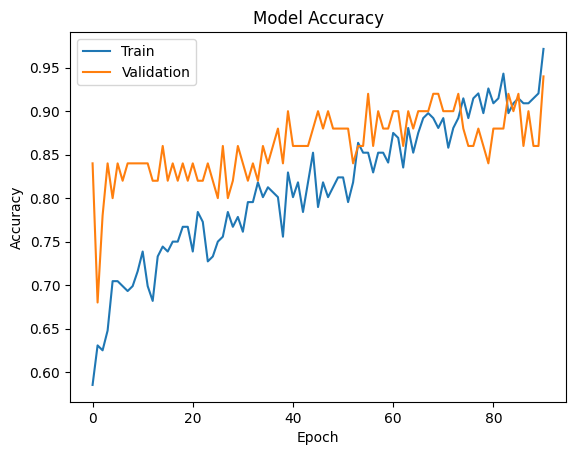

In [24]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

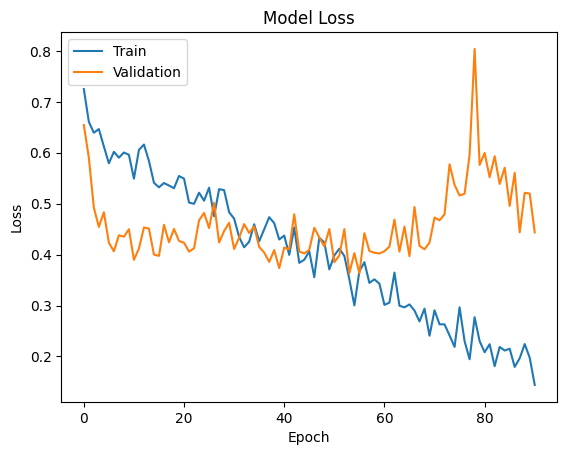

In [25]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [26]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Prediction Probability:
[[0.12524225]]

Predicted Class:
no


In [36]:
image_path = "sample-yes.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Prediction Probability:
[[0.928506]]

Predicted Class:
yes


In [40]:
model.save('brain_tumor.keras')
model.save('brain_tumoer.h5')

In [38]:
model.export("brain_tumor")

INFO:tensorflow:Assets written to: brain_tumor/assets


INFO:tensorflow:Assets written to: brain_tumor/assets


Saved artifact at 'brain_tumor'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_828')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  17218093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218094288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218095248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218094480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218095632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218095440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218096016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218095824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218096400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218096208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17218096784: TensorSpec(shape=(), dtype=tf.resource, na